In [26]:
import pandas as pd

df = pd.read_csv(  r"C:\Sqldata\covid19_cleaned.csv",
    parse_dates=["Date"])

print(sorted(df["Location"].unique()))
print("=============================================================")
print(df.dtypes)

['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antarctica', 'Antigua And Barbuda', 'Argentina', 'Armenia', 'Australia - Australian Capital Territory', 'Australia - New South Wales', 'Australia - Northern Territory', 'Australia - Queensland', 'Australia - South Australia', 'Australia - Tasmania', 'Australia - Victoria', 'Australia - Western Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia And Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burma', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada - Alberta', 'Canada - British Columbia', 'Canada - Diamond Princess', 'Canada - Grand Princess', 'Canada - Manitoba', 'Canada - New Brunswick', 'Canada - Newfoundland And Labrador', 'Canada - Northwest Territories', 'Canada - Nova Scotia', 'Canada - Nunavut', 'Canada - Ontario', 'Canada - Prince Edward Island', 'Canada - Quebec', 'Canada - Repa

In [27]:
#Case stady

country_df = df[df["Location"] == "Germany"]

print(country_df.head())
print(country_df.shape)

           Date  Confirmed  Deaths  Recovered Location
133  2020-01-22          0       0          0  Germany
419  2020-01-23          0       0          0  Germany
705  2020-01-24          0       0          0  Germany
991  2020-01-25          0       0          0  Germany
1277 2020-01-26          0       0          0  Germany
(1143, 5)


In [28]:
print("Start:", country_df["Date"].min())
print("End:", country_df["Date"].max())

Start: 2020-01-22 00:00:00
End: 2023-03-09 00:00:00


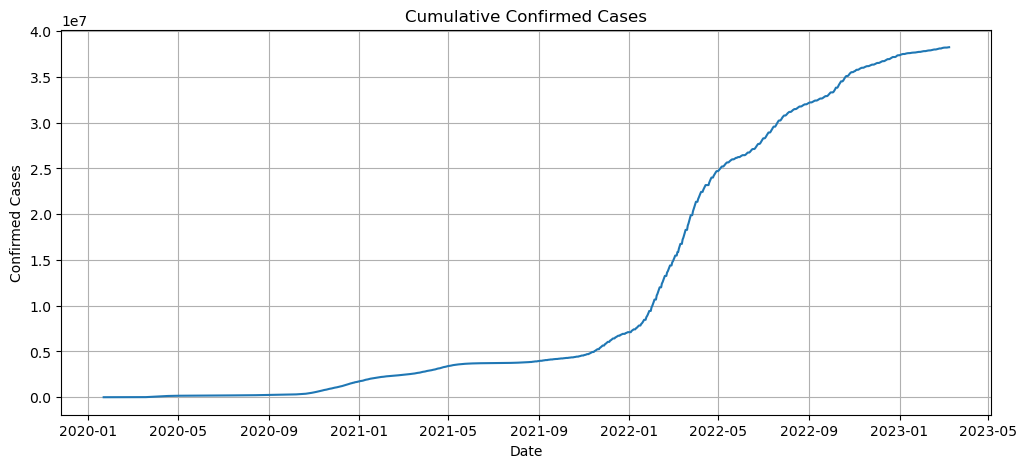

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(country_df["Date"], country_df["Confirmed"])
plt.title("Cumulative Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.grid(True)
plt.show()

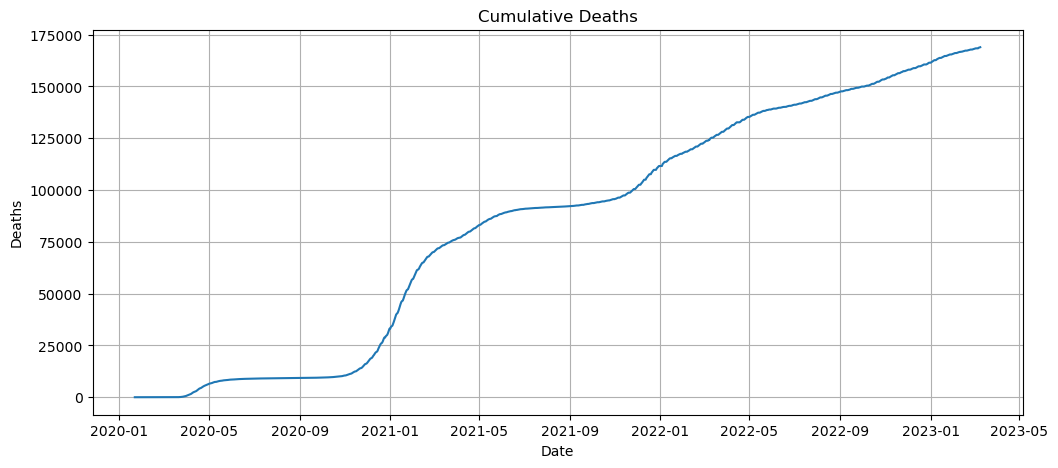

In [30]:
plt.figure(figsize=(12,5))
plt.plot(country_df["Date"], country_df["Deaths"])
plt.title("Cumulative Deaths")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.grid(True)
plt.show()

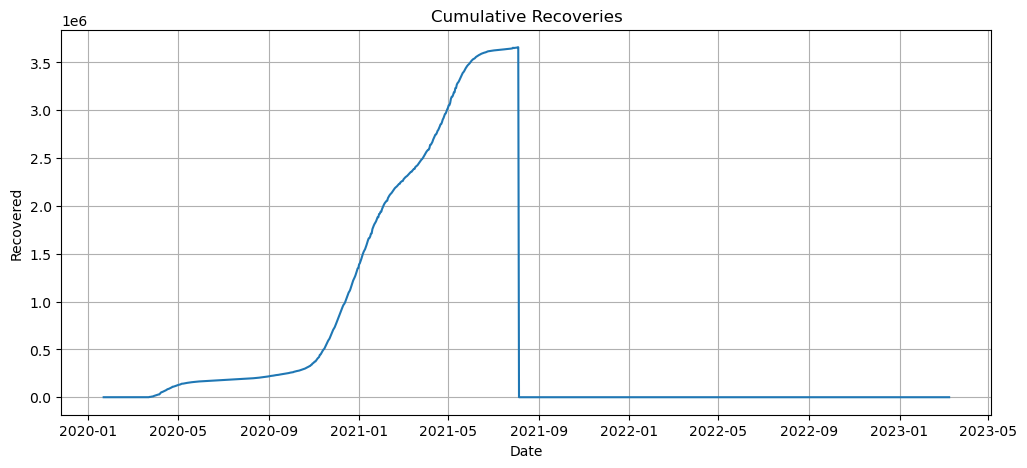

In [31]:
plt.figure(figsize=(12,5))
plt.plot(country_df["Date"], country_df["Recovered"])
plt.title("Cumulative Recoveries")
plt.xlabel("Date")
plt.ylabel("Recovered")
plt.grid(True)
plt.show()

In [32]:
#explore if the pattren of recovery stop in same date in other countries 
country2_df = df[df["Location"] == "Korea, South"]
country3_df = df[df["Location"] == "Spain"]

######################################################################

last_valid = country_df[country_df["Recovered"] > 0].iloc[-1]

print("Last valid recovery date:", last_valid["Date"])
print("Recovered:", last_valid["Recovered"])

print("Rows before cutoff:",
      len(country_df[country_df["Recovered"] > 0]))


######################################################################

last2_valid = country2_df[country2_df["Recovered"] > 0].iloc[-1]

print("Last valid recovery date:", last2_valid["Date"])
print("Recovered:", last2_valid["Recovered"])

print("Rows before cutoff:",
      len(country2_df[country2_df["Recovered"] > 0]))

#####################################################################

last3_valid = country3_df[country3_df["Recovered"] > 0].iloc[-1]

print("Last valid recovery date:", last3_valid["Date"])
print("Recovered:", last3_valid["Recovered"])

print("Rows before cutoff:",
      len(country3_df[country3_df["Recovered"] > 0]))





Last valid recovery date: 2021-08-04 00:00:00
Recovered: 3659260
Rows before cutoff: 539
Last valid recovery date: 2021-08-04 00:00:00
Recovered: 180719
Rows before cutoff: 545
Last valid recovery date: 2021-08-04 00:00:00
Recovered: 150376
Rows before cutoff: 537


In [33]:

start_date = country_df.loc[
    country_df["Confirmed"] > 0, "Date"
].min()

number_of_cases= country_df.loc[
    country_df["Confirmed"] > 0,
].min()

end_date = country_df.loc[
    country_df["Recovered"] > 0, "Date"
].max()

number_of_recoverd =country_df.loc[
    country_df["Recovered"] > 0,
].max()
country_df = country_df[
    (country_df["Date"] >= start_date) &
    (country_df["Date"] <= end_date)
].copy()

print("Start:", start_date.date())
print("Number of cases:",number_of_cases)
print("================================================================")
print("End:", end_date.date())
print("Number of recoverd",number_of_recoverd)
print("================================================================")
print("Rows:", len(country_df))

Start: 2020-01-27
Number of cases: Date         2020-01-27 00:00:00
Confirmed                      1
Deaths                         0
Recovered                      0
Location                 Germany
dtype: object
End: 2021-08-04
Number of recoverd Date         2021-08-04 00:00:00
Confirmed                3777446
Deaths                     91704
Recovered                3659260
Location                 Germany
dtype: object
Rows: 556


In [34]:
trimmed_data = []

# Process each country
for country in df["Location"].unique():

    country_df = df[df["Location"] == country].copy()

    # Skip countries with no confirmed cases
    if (country_df["Confirmed"] > 0).sum() == 0:
        continue

    # Skip countries with no recovery data
    if (country_df["Recovered"] > 0).sum() == 0:
        continue

    # Find the modeling period
    start_date = country_df.loc[
        country_df["Confirmed"] > 0, "Date"
    ].min()

    end_date = country_df.loc[
        country_df["Recovered"] > 0, "Date"
    ].max()

    # Keep only the selected period
    country_trimmed = country_df[
        (country_df["Date"] >= start_date) &
        (country_df["Date"] <= end_date)
    ].copy()

    trimmed_data.append(country_trimmed)

# Combine all countries
trimmed_df = pd.concat(trimmed_data, ignore_index=True)

print(trimmed_df.head())
print(trimmed_df.shape)

        Date  Confirmed  Deaths  Recovered     Location
0 2020-02-24          5       0          0  Afghanistan
1 2020-02-25          5       0          0  Afghanistan
2 2020-02-26          5       0          0  Afghanistan
3 2020-02-27          5       0          0  Afghanistan
4 2020-02-28          5       0          0  Afghanistan
(127831, 5)


In [35]:
trimmed_df.to_csv(
    r"C:\Sqldata\covid19_modeling.csv",
    index=False
)

In [38]:
summary = []

for country in trimmed_df["Location"].unique():

    temp = trimmed_df[trimmed_df["Location"] == country]

    summary.append({
        "Country": country,
        "Start Date": temp["Date"].min().date(),
        "End Date": temp["Date"].max().date(),
        "confirmed total":temp["Confirmed"].max(),
        "Deaths Total": temp["Deaths"].max(),
        "Recovered Total": temp["Recovered"].max(),
        "Rows": len(temp)
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

                Country  Start Date    End Date  confirmed total  \
0           Afghanistan  2020-02-24  2021-08-04           148933   
1               Albania  2020-03-09  2021-08-04           133310   
2               Algeria  2020-02-25  2021-08-04           176724   
3               Andorra  2020-03-02  2021-08-04            14797   
4                Angola  2020-03-20  2021-08-04            43158   
..                  ...         ...         ...              ...   
246             Vietnam  2020-01-23  2021-08-04           181756   
247  West Bank And Gaza  2020-03-05  2021-08-04           317404   
248               Yemen  2020-04-10  2021-08-04             7096   
249              Zambia  2020-03-18  2021-08-04           197791   
250            Zimbabwe  2020-03-20  2021-08-04           113526   

     Deaths Total  Recovered Total  Rows  
0            6836            82586   528  
1            2457           130314   514  
2            4404           118409   527  
3          

In [40]:
summary_df.to_csv(
    r"C:\Sqldata\country_model_summary.csv",
    index=False
)